In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

customers = pd.read_csv("Data/retail_analytics/olist_customers_dataset.csv")
orders = pd.read_csv("Data/retail_analytics/olist_orders_dataset.csv")
payments = pd.read_csv("Data/retail_analytics/olist_order_payments_dataset.csv")

In [3]:
customers.shape
orders.shape
payments.shape

(103886, 5)

In [4]:
customers["customer_unique_id"].nunique()

96096

In [5]:
orders["order_id"].nunique()

99441

In [6]:
payments["payment_value"].sum()

np.float64(16008872.120000001)

In [7]:
payments["payment_value"].sum() / orders["order_id"].nunique()

np.float64(160.98864774087147)

In [8]:
total_customers = customers["customer_unique_id"].nunique()
total_orders = orders["order_id"].nunique()
total_revenue = payments["payment_value"].sum()
aov = total_revenue / total_orders

print("Total Customers:", total_customers)
print("Total Orders:", total_orders)
print("Total Revenue:", round(total_revenue, 2))
print("Average Order Value:", round(aov, 2))

Total Customers: 96096
Total Orders: 99441
Total Revenue: 16008872.12
Average Order Value: 160.99


In [9]:
customer_orders = customers.merge(
    orders,
    on="customer_id",
    how="inner"
)

customer_orders_payments = customer_orders.merge(
    payments,
    on="order_id",
    how="inner"
)

customer_orders_payments.shape

(103886, 16)

In [10]:
customer_revenue = customer_orders_payments.groupby(
    "customer_unique_id"
)["payment_value"].sum().sort_values(ascending=False)

customer_revenue.head(10)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13664.08
46450c74a0d8c5ca9395da1daac6c120     9553.02
da122df9eeddfedc1dc1f5349a1a690c     7571.63
763c8b1c9c68a0229c42c9fc6f662b93     7274.88
dc4802a71eae9be1dd28f5d788ceb526     6929.31
459bef486812aa25204be022145caa62     6922.21
ff4159b92c40ebe40454e3e6a7c35ed6     6726.66
4007669dec559734d6f53e029e360987     6081.54
5d0a2980b292d049061542014e8960bf     4809.44
eebb5dda148d3893cdaf5b5ca3040ccb     4764.34
Name: payment_value, dtype: float64

In [11]:
customer_revenue.describe()

count    96095.000000
mean       166.594226
std        231.428912
min          0.000000
25%         63.120000
50%        108.000000
75%        183.530000
max      13664.080000
Name: payment_value, dtype: float64

In [12]:
customer_segments = customer_revenue.reset_index()

customer_segments["segment"] = np.where(
    customer_segments["payment_value"] > 183.53,
    "High Value",
    np.where(
        customer_segments["payment_value"] >= 63.12,
        "Medium Value",
        "Low Value"
    )
)

customer_segments.head()

,customer_unique_id,payment_value,segment
0,0a0a92112bd4c708ca5fde585afaa872,13664.08,High Value
1,46450c74a0d8c5ca9395da1daac6c120,9553.02,High Value
2,da122df9eeddfedc1dc1f5349a1a690c,7571.63,High Value
3,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,High Value
4,dc4802a71eae9be1dd28f5d788ceb526,6929.31,High Value


In [13]:
segment_counts = customer_segments["segment"].value_counts()

segment_counts

segment
Medium Value    48059
High Value      24021
Low Value       24015
Name: count, dtype: int64

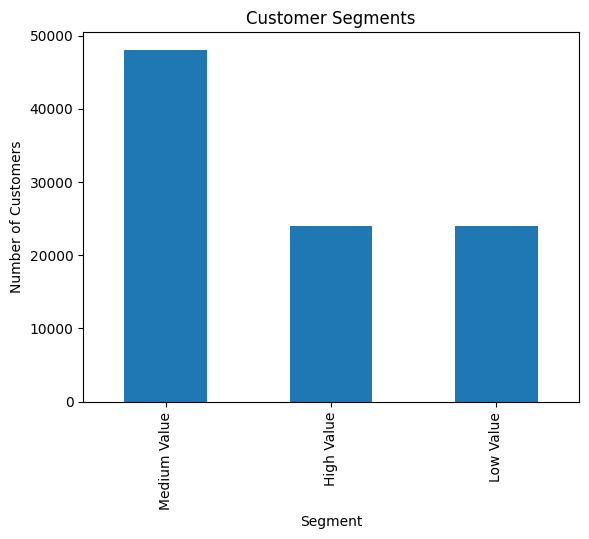

In [14]:
segment_counts.plot(
    kind="bar"
)

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

In [15]:
customer_orders = customers.merge(
    orders,
    on="customer_id",
    how="inner"
)

final_df = customer_orders.merge(
    payments,
    on="order_id",
    how="inner"
)

final_df.shape

(103886, 16)

In [16]:
final_df.to_csv(
    "powerbi_customer_analysis.csv",
    index=False
)

In [17]:
final_df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'order_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

In [18]:
import os

os.getcwd()

'c:\\SQL Project\\customer_analytics_python'

In [19]:
import os

os.listdir()

['analysis.ipynb',
 'customer_segmentation.ipynb',
 'Data',
 'powerbi_customer_analysis.csv']

In [20]:
final_df.to_csv(
    "Data/powerbi_customer_analysis.csv",
    index=False
)